In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures,RobustScaler,StandardScaler,MinMaxScaler
from imblearn.over_sampling import SMOTE

In [40]:
Train = pd.read_csv('train.csv')
Train_2 = pd.read_csv('train.csv')
Test = pd.read_csv('test.csv')
Sub = pd.read_csv('sample_submission.csv')

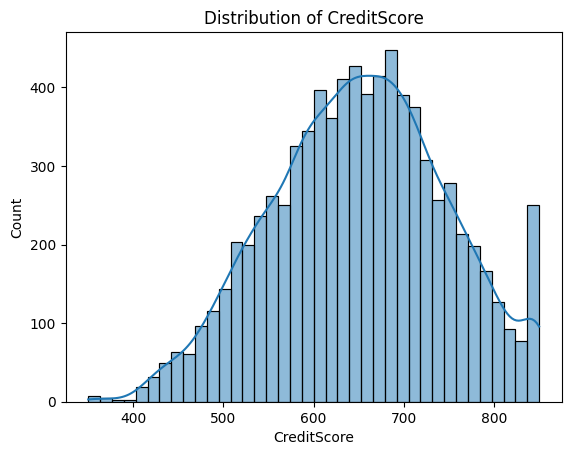

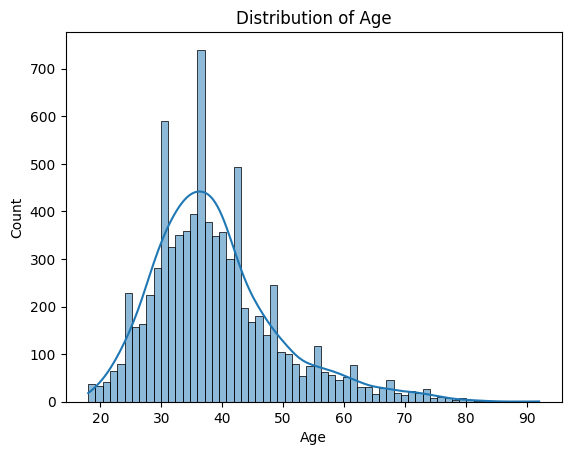

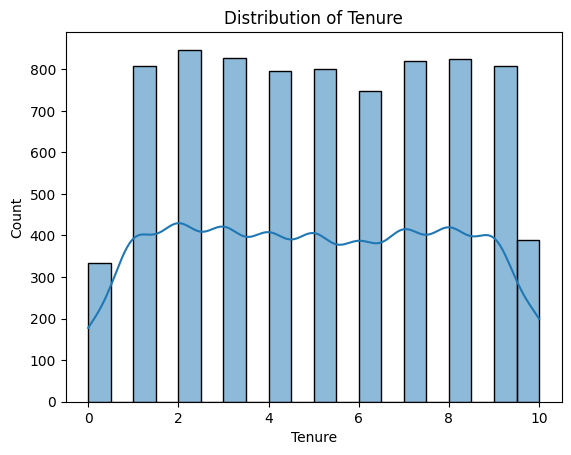

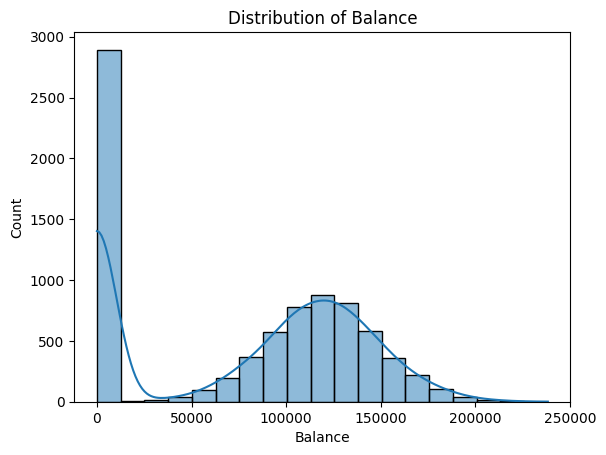

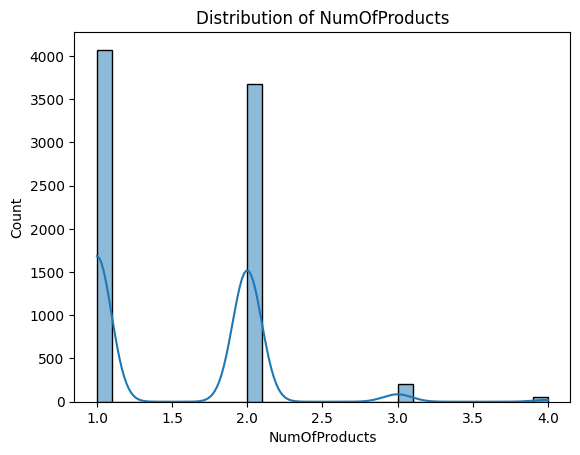

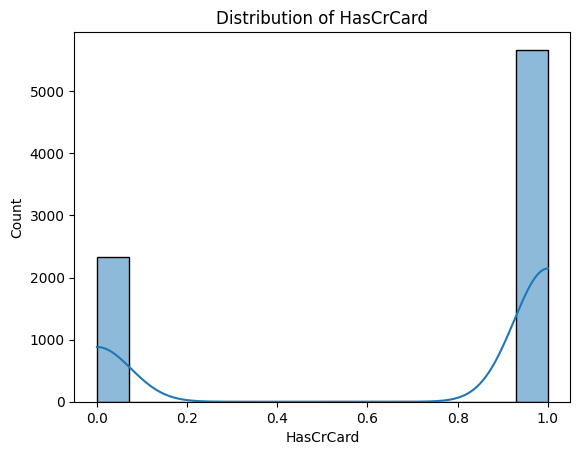

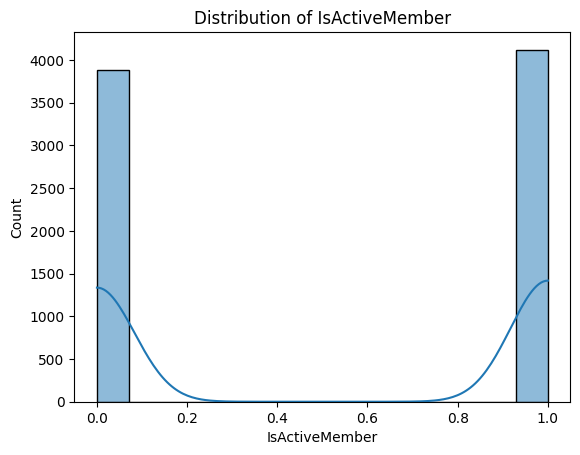

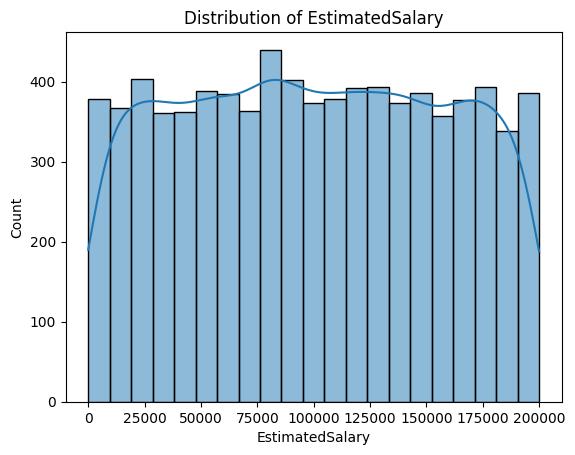

In [41]:
numerical_cols = Train.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    if col not in ['RowNumber', 'CustomerId', 'Exited']:
      sns.histplot(Train[col], kde=True)
      plt.title(f'Distribution of {col}')
      plt.show()

In [42]:
numerical_cols = Train.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
  if col not in ['RowNumber', 'CustomerId', 'Exited']:
    print(f"{col}: {Train[col].skew()}")

CreditScore: -0.07954036404354221
Age: 1.0357058511787398
Tenure: 0.013124064640687135
Balance: -0.14172122228890083
NumOfProducts: 0.7559843280505546
HasCrCard: -0.9190908001277238
IsActiveMember: -0.05953751196541758
EstimatedSalary: 0.00712627126665978


In [43]:
Train

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2152,15588614,Walton,753,France,Male,57,7,0.00,1,1,0,159475.08,1
1,8393,15641158,Belcher,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1
2,5007,15750014,Chikere,755,Germany,Female,37,0,113865.23,2,1,1,117396.25,0
3,4118,15663964,Pagnotto,561,France,Male,37,5,0.00,2,1,0,83093.25,0
4,7183,15573520,Rhodes,692,Germany,Male,49,6,110540.43,2,0,1,107472.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,4556,15733261,Kung,688,Spain,Female,35,6,0.00,1,1,0,25488.43,1
7996,4645,15714240,Ponomarev,712,Spain,Male,74,5,0.00,2,0,0,151425.82,0
7997,8943,15709780,Azuka,667,France,Female,37,9,71786.90,2,1,1,67734.79,0
7998,2936,15689425,Olejuru,687,Spain,Male,35,8,100988.39,2,1,0,22247.27,0


In [44]:
Train.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,8000.0,4.990433e+03,2896.482331,1.00,2.461750e+03,4.987500e+03,7.509500e+03,10000.00
CustomerId,8000.0,1.569088e+07,71936.185838,15565701.00,1.562869e+07,1.568995e+07,1.575327e+07,15815690.00
CreditScore,8000.0,6.507525e+02,96.596432,350.00,5.840000e+02,6.520000e+02,7.170000e+02,850.00
Age,8000.0,3.894662e+01,10.526876,18.00,3.200000e+01,3.700000e+01,4.400000e+01,92.00
Tenure,8000.0,5.016625e+00,2.896791,0.00,3.000000e+00,5.000000e+00,8.000000e+00,10.00
Balance,8000.0,7.638121e+04,62302.053597,0.00,0.000000e+00,9.705515e+04,1.276332e+05,238387.56
NumOfProducts,8000.0,1.529500e+00,0.581741,1.00,1.000000e+00,1.000000e+00,2.000000e+00,4.00
HasCrCard,8000.0,7.087500e-01,0.454367,0.00,0.000000e+00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,8000.0,5.148750e-01,0.499810,0.00,0.000000e+00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,8000.0,9.973081e+04,57335.116540,11.58,5.069182e+04,9.944694e+04,1.485277e+05,199992.48


In [45]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        8000 non-null   int64  
 1   CustomerId       8000 non-null   int64  
 2   Surname          8000 non-null   object 
 3   CreditScore      8000 non-null   int64  
 4   Geography        8000 non-null   object 
 5   Gender           8000 non-null   object 
 6   Age              8000 non-null   int64  
 7   Tenure           8000 non-null   int64  
 8   Balance          8000 non-null   float64
 9   NumOfProducts    8000 non-null   int64  
 10  HasCrCard        8000 non-null   int64  
 11  IsActiveMember   8000 non-null   int64  
 12  EstimatedSalary  8000 non-null   float64
 13  Exited           8000 non-null   int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 875.1+ KB


In [46]:
pd.crosstab(Train['Gender'], Train['Exited'])

Exited,0,1
Gender,,
Female,2707,906
Male,3663,724


In [47]:
pd.crosstab(Train['Gender'], Train['Exited'], normalize='index')

Exited,0,1
Gender,,
Female,0.749239,0.250761
Male,0.834967,0.165033


In [48]:
pd.crosstab(Train['Geography'], Train['Exited'], normalize='index')

Exited,0,1
Geography,,
France,0.840972,0.159028
Germany,0.669327,0.330673
Spain,0.834166,0.165834


In [49]:
pd.crosstab(Train['Age'], Train['Exited'], normalize='index')

Exited,0,1
Age,,
18,0.941176,0.058824
19,1.000000,0.000000
20,0.939394,0.060606
21,0.951220,0.048780
22,0.859375,0.140625
...,...,...
82,1.000000,0.000000
83,1.000000,0.000000
84,0.500000,0.500000


In [50]:
px.histogram(Train, x='NumOfProducts', color='Exited')

In [51]:
cati = Train.select_dtypes(include=['object'])
for col in cati:
    fig = px.histogram(Train, x=col,color='Exited', title=f'Distribution of {col}')
    fig.show()

In [52]:
cat = Train.select_dtypes(include=['object'])
for col in cat:
  fig = px.box(Train, x=col, color='Exited')
  print(f'Boxplot of {col}')
  fig.show()

Boxplot of Surname


Boxplot of Geography


Boxplot of Gender


In [53]:
numerical_cols = Train.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
	if col != 'Exited':
		fig = px.box(Train, x='Exited', y=col, title=f'Boxplot of {col} by Exited')
		fig.show()

In [54]:
Train.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [55]:
Train = Train.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
Test = Test.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [ ]:
#This was my first attempt FE the data
# for data in [Train,Test]:
#   data['Stability'] = (data['Balance'] * data['CreditScore'])/data['EstimatedSalary']
#   data['Liquidity'] = data['Balance'] / data['EstimatedSalary']
#   data['Senior'] = (data['Age'] > 50).astype(int)
#   data['Young'] = (data['Age'] < 46).astype(int)
#   data['client_footprint'] = data['Balance'] + data['EstimatedSalary'] + data['CreditScore']
#   data['Empty_balance'] = (data['Balance'] == 0).astype(int)
#   data['Balance_Product'] = data['Balance'] / data['NumOfProducts']
#   data['Inactive_no_bal']  = ((data['IsActiveMember'] == 0) & (data['Balance'] == 0)).astype(int)


In [57]:
for data in [Train,Test]:
  data['New_Tenure'] = data['Tenure'].replace(0,1)
  data['LOG_Salary'] = np.log1p(data['EstimatedSalary'])
  data['Stability'] = (data['Balance'] * data['CreditScore'])/data['EstimatedSalary']
  data['Liquidity'] = data['Balance'] / data['EstimatedSalary']
  data['Germany_Old'] = ((data['Geography'] == 'Germany') & (data['Age'] > 45)).astype(int)
  data['Germany_Int'] = (data['Geography'] == 'Germany').astype(int)
  data['Germany_young'] = (data['Geography'] == 'Germany') & (data['Age'] < 35).astype(int)
  data['Male_tenure'] = (data['Gender'] == 'Male') / data['New_Tenure']
  data['Male_age'] = (data['Gender'] == 'Male') * data['Age']
  data['Female_balance'] = (data['Gender'] == 'Female') * data['Balance']
  data['Male_balance'] = (data['Gender'] == 'Male') * data['Balance']
  data['Number_of_Products'] = (data['NumOfProducts']).astype(int)
  data['Senior'] = (data['Age'] > 45).astype(int)
  data['Young'] = (data['Age'] < 35).astype(int)
  data['Young_Age_Tenure'] = (data['Age']<35) / data['New_Tenure']
  data['Senior_Age_Tenure'] = (data['Age']>45) / data['New_Tenure']
  data['Age2'] = data['Age']**2
  data['Balance_Age'] = data['Balance'] / data['Age']
  data['NumProd_Activity'] = data['NumOfProducts'] + data['IsActiveMember']
  data['NumOfProducts'] = data['NumOfProducts'].astype(int)
  data['client_footprint'] = data['Balance'] + data['EstimatedSalary'] + data['CreditScore']
  data['Empty_balance'] = (data['Balance'] == 0).astype(int)
  data['Balance_Product'] = data['Balance'] / data['NumOfProducts']
  data['Inactive_no_bal']  = ((data['IsActiveMember'] == 0) & (data['Balance'] == 0)).astype(int)
  Train.drop('New_Tenure', axis=1)

In [58]:
from sklearn.preprocessing import LabelEncoder
le_geo = LabelEncoder()
le_gen = LabelEncoder()
Train['Geography'] = le_geo.fit_transform(Train['Geography'])
Train['Gender'] = le_gen.fit_transform(Train['Gender'])
Test['Geography'] = le_geo.transform(Test['Geography'])
Test['Gender'] = le_gen.transform(Test['Gender'])

In [59]:
X = Train.drop('Exited', axis=1)
y = Train['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('SMOTE', SMOTE(random_state=42)),
    ('rfc', RandomForestClassifier(n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42))

])
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('SMOTE', SMOTE(random_state=42)),
                ('rfc',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=5,
                                        random_state=42))])

In [61]:
y_train_pred = model_pipeline.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      5096
           1       0.70      0.84      0.76      1304

    accuracy                           0.89      6400
   macro avg       0.83      0.88      0.85      6400
weighted avg       0.91      0.89      0.90      6400



In [62]:
y_pred = model_pipeline.predict(Test)

In [63]:
Sub['Exited'] = y_pred

In [ ]:
# Sub.to_csv('sub_file.csv', index=False)